# Train a Speech / Noise Separator

This notebook trains a 2-source audio separator on `dataset_out`.
It expects a `metadata.csv` file and the `train`, `val`, and `test` split folders.

For Kaggle, use `GPU -> T4`, `Internet -> Off`, and add the dataset as an input.
For local use, keep the notebook in the same folder as `dataset_out` and run it normally.

In [1]:
import csv
import json
import random
import shutil
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import soundfile as sf
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
@dataclass
class Config:
    dataset_dir: str = "/kaggle/input/datasets/saranjpalani/seperatorspeechv4/SyntheticSportsCommentary"
    # FIX: always resolve to an absolute path so files land in /kaggle/working
    output_dir: str = str(
        Path("/kaggle/working/separator_output") if Path("/kaggle/input").exists()
        else Path("separator_output").resolve()
    )
    model_name: str = "separator_model"
    epochs: int = 20
    batch_size: int = 32
    learning_rate: float = 3e-4
    weight_decay: float = 1e-5
    sample_rate: int = 16000
    segment_seconds: float = 5.0

    # Early stopping
    early_stop_patience: int = 5
    early_stop_min_delta: float = 1e-4

config = Config()
config.device = device
print(f"output_dir -> {config.output_dir}")
config

output_dir -> /kaggle/working/separator_output


Config(dataset_dir='/kaggle/input/datasets/saranjpalani/seperatorspeechv4/SyntheticSportsCommentary', output_dir='/kaggle/working/separator_output', model_name='separator_model', epochs=20, batch_size=32, learning_rate=0.0003, weight_decay=1e-05, sample_rate=16000, segment_seconds=5.0, early_stop_patience=5, early_stop_min_delta=0.0001)

In [3]:
def load_audio(path: Path) -> np.ndarray:
    audio, _ = sf.read(path, dtype="float32")
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    return audio.astype(np.float32)

def rms_normalize(audio, eps=1e-8):
    rms = np.sqrt(np.mean(audio ** 2) + eps)
    return audio / rms

def remix_with_random_snr(speech, noise):
    speech = rms_normalize(speech)
    noise = rms_normalize(noise)

    snr_db = random.uniform(-5, 15)

    speech_power = np.mean(speech ** 2)
    noise_power = np.mean(noise ** 2)

    scale = np.sqrt(
        speech_power /
        ((10 ** (snr_db / 10)) * noise_power + 1e-8)
    )

    noise = noise * scale

    mixture = speech + noise
    peak = np.max(np.abs(mixture))

    if peak > 0.99:
        mixture = mixture / peak
        speech = speech / peak
        noise = noise / peak

    return mixture.astype(np.float32), speech.astype(np.float32), noise.astype(np.float32)

def align_and_crop(mixture, speech, noise, target_samples, random_crop):
    min_length = min(len(mixture), len(speech), len(noise))
    mixture = mixture[:min_length]
    speech = speech[:min_length]
    noise = noise[:min_length]

    if min_length >= target_samples:
        if random_crop:
            start = random.randint(0, min_length - target_samples)
        else:
            start = (min_length - target_samples) // 2
        end = start + target_samples
        mixture = mixture[start:end]
        speech = speech[start:end]
        noise = noise[start:end]
    else:
        pad_width = target_samples - min_length
        mixture = np.pad(mixture, (0, pad_width))
        speech = np.pad(speech, (0, pad_width))
        noise = np.pad(noise, (0, pad_width))

    return mixture, speech, noise

class AudioSeparationDataset(Dataset):
    def __init__(self, dataset_dir, split, sample_rate, segment_seconds):
        self.base_dir = Path(dataset_dir) / split
        self.split = split
        self.sample_rate = sample_rate
        self.target_samples = int(sample_rate * segment_seconds)
        self.random_crop = (split == "train")

        speech_dir = self.base_dir / "speech"
        if not speech_dir.exists():
            raise FileNotFoundError(f"Could not find directory: {speech_dir}")
            
        # Scan the directory and strictly sort the names to keep everything aligned
        self.file_names = sorted([f.name for f in speech_dir.glob("*.wav")])
        
        if not self.file_names:
            raise ValueError(f"No .wav files found in {speech_dir}")

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        filename = self.file_names[idx]

        # Maps exactly to your tree directory names ('crowd' and 'mix')
        speech_path  = self.base_dir / "speech" / filename
        noise_path   = self.base_dir / "crowd" / filename
        mixture_path = self.base_dir / "mix" / filename

        speech  = load_audio(speech_path)
        noise   = load_audio(noise_path)
        mixture = load_audio(mixture_path)

        mixture, speech, noise = align_and_crop(
            mixture, speech, noise, self.target_samples, self.random_crop
        )

        speech = rms_normalize(speech)
        noise = rms_normalize(noise)
        
        if self.split == "train":
            mixture, speech, noise = remix_with_random_snr(speech, noise)
        else:
            mixture = speech + noise
            peak = np.max(np.abs(mixture))
            if peak > 0.99:
                mixture = mixture / peak
                speech = speech / peak
                noise = noise / peak

        return {
            "mixture": torch.from_numpy(mixture.astype(np.float32)).unsqueeze(0),
            "speech": torch.from_numpy(speech.astype(np.float32)).unsqueeze(0),
            "noise": torch.from_numpy(noise.astype(np.float32)).unsqueeze(0),
        }

# Instantiate datasets matching your configurations
train_dataset = AudioSeparationDataset(config.dataset_dir, "train", config.sample_rate, config.segment_seconds)
val_dataset   = AudioSeparationDataset(config.dataset_dir, "val",   config.sample_rate, config.segment_seconds)
test_dataset  = AudioSeparationDataset(config.dataset_dir, "test",  config.sample_rate, config.segment_seconds)

print(f"Dataset successfully loaded! Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Dataset successfully loaded! Train: 576, Val: 72, Test: 72


In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dilation=1):
        super().__init__()

        padding = ((31 - 1) // 2) * dilation

        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=31,
                padding=padding,
                dilation=dilation
            ),
            nn.GroupNorm(1, out_ch),
            nn.GELU(),

            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=31,
                padding=padding,
                dilation=dilation
            ),
            nn.GroupNorm(1, out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class TCNBlock(nn.Module):
    def __init__(self, channels, dilation):
        super().__init__()

        self.conv1 = nn.Conv1d(
            channels,
            channels,
            kernel_size=3,
            padding=dilation,
            dilation=dilation
        )

        self.norm1 = nn.GroupNorm(1, channels)

        self.conv2 = nn.Conv1d(
            channels,
            channels,
            kernel_size=3,
            padding=dilation,
            dilation=dilation
        )

        self.norm2 = nn.GroupNorm(1, channels)

    def forward(self, x):
        residual = x

        x = self.conv1(x)
        x = self.norm1(x)
        x = F.gelu(x)

        x = self.conv2(x)
        x = self.norm2(x)

        return F.gelu(x + residual)


class UNet1D(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(1, 32, dilation=1)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = ConvBlock(32, 64, dilation=2)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = ConvBlock(64, 128, dilation=4)
        self.pool3 = nn.MaxPool1d(2)

        self.bottleneck = ConvBlock(128, 256, dilation=8)

        self.tcn = nn.Sequential(
            TCNBlock(256, 1),
            TCNBlock(256, 2),
            TCNBlock(256, 4),
            TCNBlock(256, 8),
        )

        self.up3 = nn.ConvTranspose1d(256, 128, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(256, 128, dilation=4)

        self.up2 = nn.ConvTranspose1d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64, dilation=2)

        self.up1 = nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32, dilation=1)

        self.speech_out = nn.Conv1d(32, 1, kernel_size=1)

    def _pad_to(self, x, ref):
        diff = ref.size(-1) - x.size(-1)
        if diff > 0:
            x = nn.functional.pad(x, (0, diff))
        elif diff < 0:
            x = x[..., :ref.size(-1)]
        return x

    def forward(self, mixture):
        e1 = self.enc1(mixture)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        b = self.bottleneck(p3)
        b = self.tcn(b)

        d3 = self.dec3(torch.cat([self._pad_to(self.up3(b), e3), e3], dim=1))
        d2 = self.dec2(torch.cat([self._pad_to(self.up2(d3), e2), e2], dim=1))
        d1 = self.dec1(torch.cat([self._pad_to(self.up1(d2), e1), e1], dim=1))

        speech = self.speech_out(d1)
        noise = mixture - speech

        return speech, noise


def si_snr_loss(pred, target, eps=1e-8):
    target = target - target.mean(dim=-1, keepdim=True)
    pred = pred - pred.mean(dim=-1, keepdim=True)

    s_target = (
        torch.sum(pred * target, dim=-1, keepdim=True)
        * target
        / (torch.sum(target ** 2, dim=-1, keepdim=True) + eps)
    )

    e_noise = pred - s_target

    si_snr = 10 * torch.log10(
        (torch.sum(s_target ** 2, dim=-1) + eps)
        / (torch.sum(e_noise ** 2, dim=-1) + eps)
    )

    return -si_snr.mean()


def multi_resolution_stft_loss(pred, target):
    fft_sizes = [512, 1024, 2048]
    hop_sizes = [128, 256, 512]

    total_loss = 0.0

    for fft, hop in zip(fft_sizes, hop_sizes):
        window = torch.hann_window(fft).to(pred.device)
        pred_stft = torch.stft(
            pred.squeeze(1),
            n_fft=fft,
            hop_length=hop,
            window=window,
            return_complex=True
        )

        target_stft = torch.stft(
            target.squeeze(1),
            n_fft=fft,
            hop_length=hop,
            window=window,
            return_complex=True
        )

        pred_mag = pred_stft.abs()
        target_mag = target_stft.abs()

        total_loss += F.l1_loss(pred_mag, target_mag)

    return total_loss / len(fft_sizes)


def separation_loss(
    speech_pred,
    noise_pred,
    speech_target,
    noise_target,
    mixture
):
    speech_sisnr = si_snr_loss(speech_pred, speech_target)
    noise_sisnr = si_snr_loss(noise_pred, noise_target)

    speech_stft = multi_resolution_stft_loss(speech_pred, speech_target)
    noise_stft = multi_resolution_stft_loss(noise_pred, noise_target)

    waveform_loss = (
        F.l1_loss(speech_pred, speech_target)
        + F.l1_loss(noise_pred, noise_target)
    )

    total = (
        0.70 * speech_sisnr +
        0.15 * noise_sisnr +
        0.05 * speech_stft +
        0.05 * noise_stft +
        0.05 * waveform_loss
    )

    return total


model = UNet1D().to(config.device)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = torch.nn.DataParallel(model)

print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using 2 GPUs
Model Parameters: 7,701,857


In [5]:
def train_epoch(model, train_loader, optimizer):
    model.train()
    total_loss = 0.0
    for batch_idx, batch in enumerate(train_loader, start=1):
        mixture = batch["mixture"].to(config.device)
        speech  = batch["speech"].to(config.device)
        noise   = batch["noise"].to(config.device)
        speech_pred, noise_pred = model(mixture)
        loss = separation_loss(speech_pred, noise_pred, speech, noise, mixture)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        if batch_idx % 10 == 0:
            print(f"batch {batch_idx}/{len(train_loader)} loss={loss.item():.4f}")
    return total_loss / max(1, len(train_loader))


def evaluate(model, data_loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in data_loader:
            mixture = batch["mixture"].to(config.device)
            speech  = batch["speech"].to(config.device)
            noise   = batch["noise"].to(config.device)
            speech_pred, noise_pred = model(mixture)
            loss = separation_loss(speech_pred, noise_pred, speech, noise, mixture)
            total_loss += loss.item()
    return total_loss / max(1, len(data_loader))


train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,
                          num_workers=4, pin_memory=(config.device == "cuda"), persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=config.batch_size, shuffle=False,
                          num_workers=4, pin_memory=(config.device == "cuda"), persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=config.batch_size, shuffle=False,
                          num_workers=4, pin_memory=(config.device == "cuda"), persistent_workers=True)

optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

out_dir = Path(config.output_dir)
out_dir.mkdir(parents=True, exist_ok=True)
best_model_path = out_dir / f"{config.model_name}_best.pt"
print(f"Model will be saved to: {best_model_path}")

best_val_loss   = float("inf")
last_train_loss = None
no_improve_epochs = 0
train_losses = []
val_losses   = []

for epoch in range(1, config.epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss   = evaluate(model, val_loader)
    scheduler.step(val_loss)
    last_train_loss = train_loss
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"epoch {epoch}/{config.epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    if val_loss < (best_val_loss - config.early_stop_min_delta):
        best_val_loss = val_loss
        no_improve_epochs = 0
        # FIX: wrapped in try/except so a partial write doesn't silently corrupt the file
        try:
            torch.save(model.state_dict(), best_model_path)
            print(f"  saved -> {best_model_path}")
        except Exception as e:
            print(f"  WARNING: checkpoint save failed: {e}")
    else:
        no_improve_epochs += 1
        print(f"  no improvement for {no_improve_epochs} epoch(s)")

    if no_improve_epochs >= config.early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch}")
        break

# FIX: guard against best_model_path never being written
if best_model_path.exists():
    # FIX: weights_only=True avoids deprecation warning and is safer
    model.load_state_dict(torch.load(best_model_path, map_location=config.device, weights_only=True))
    print(f"Loaded best model from {best_model_path}")
else:
    print("WARNING: best model checkpoint not found — using current model weights")

best_model_path

Model will be saved to: /kaggle/working/separator_output/separator_model_best.pt
batch 10/18 loss=-1.2592
epoch 1/20  train_loss=-1.3223  val_loss=-2.0104
  saved -> /kaggle/working/separator_output/separator_model_best.pt
batch 10/18 loss=-3.7476
epoch 2/20  train_loss=-3.9204  val_loss=-2.6137
  saved -> /kaggle/working/separator_output/separator_model_best.pt
batch 10/18 loss=-3.6069
epoch 3/20  train_loss=-4.2442  val_loss=-2.5747
  no improvement for 1 epoch(s)
batch 10/18 loss=-4.3926
epoch 4/20  train_loss=-4.3965  val_loss=-3.0246
  saved -> /kaggle/working/separator_output/separator_model_best.pt
batch 10/18 loss=-4.9629
epoch 5/20  train_loss=-4.4772  val_loss=-2.9764
  no improvement for 1 epoch(s)
batch 10/18 loss=-5.3005
epoch 6/20  train_loss=-4.8598  val_loss=-3.4235
  saved -> /kaggle/working/separator_output/separator_model_best.pt
batch 10/18 loss=-4.6590
epoch 7/20  train_loss=-4.7856  val_loss=-3.2772
  no improvement for 1 epoch(s)
batch 10/18 loss=-2.9547
epoch 8/

PosixPath('/kaggle/working/separator_output/separator_model_best.pt')

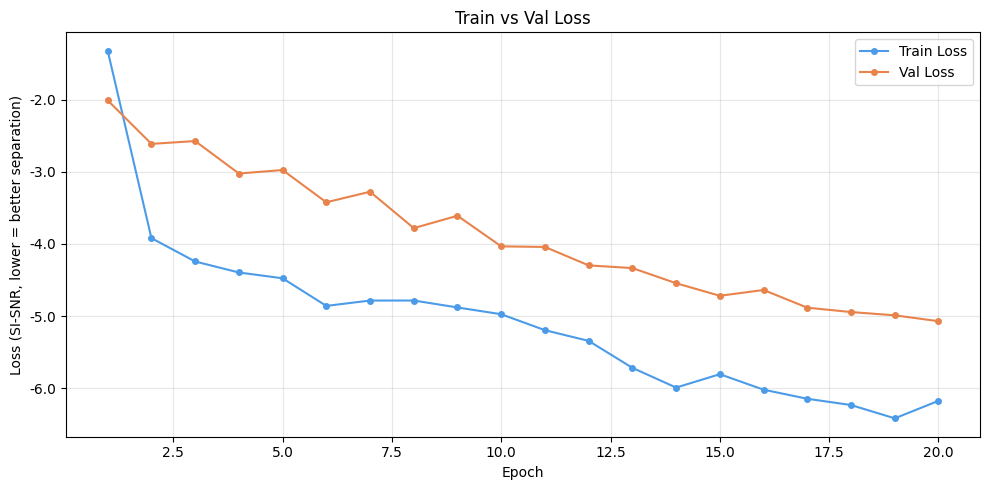

Plot saved to /kaggle/working/separator_output/loss_curve.png


In [6]:
import matplotlib.pyplot as plt

epochs_ran = list(range(1, len(train_losses) + 1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_ran, train_losses, marker='o', markersize=4, label='Train Loss', color='#4C9BE8')
ax.plot(epochs_ran, val_losses,   marker='o', markersize=4, label='Val Loss',   color='#E8834C')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (SI-SNR, lower = better separation)')
ax.set_title('Train vs Val Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))

plot_path = out_dir / 'loss_curve.png'
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot saved to {plot_path}')


In [7]:
# FIX: weights_only=True here too
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=config.device, weights_only=True))
test_loss = evaluate(model, test_loader)
print(f"test_loss = {test_loss:.4f}")
test_loss

test_loss = -5.0769


-5.07692813873291

In [8]:
config_path = out_dir / f"{config.model_name}_config.json"
with config_path.open("w", encoding="utf-8") as handle:
    json.dump({
        "model_type": "UNet1D",
        "sample_rate": config.sample_rate,
        "segment_seconds": config.segment_seconds,
        "epochs_requested": config.epochs,
        "batch_size": config.batch_size,
        "learning_rate": config.learning_rate,
        "weight_decay": config.weight_decay,
        "early_stop_patience": config.early_stop_patience,
        "early_stop_min_delta": config.early_stop_min_delta,
        "train_loss": last_train_loss,
        "val_loss": best_val_loss,
        "test_loss": float(test_loss),
        "best_model_path": str(best_model_path),
        "output_dir": str(config.output_dir),
    }, handle, indent=2)

print(f"Config saved to {config_path}")
config_path

Config saved to /kaggle/working/separator_output/separator_model_config.json


PosixPath('/kaggle/working/separator_output/separator_model_config.json')

In [9]:
def write_prediction_example(split="test", index=0, out_dir=None):
    # FIX: default to config.output_dir so predictions live alongside the model
    if out_dir is None:
        out_dir = config.output_dir

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    sample = test_dataset[index] if split == "test" else val_dataset[index]
    mixture = sample["mixture"].unsqueeze(0).to(config.device)

    model.eval()
    with torch.no_grad():
        speech_pred, noise_pred = model(mixture)

    speech_audio = speech_pred.squeeze().detach().cpu().numpy()
    noise_audio  = noise_pred.squeeze().detach().cpu().numpy()

    sf.write(out_dir / "pred_speech.flac", speech_audio, config.sample_rate)
    sf.write(out_dir / "pred_noise.flac",  noise_audio,  config.sample_rate)
    print(f"Predictions written to {out_dir}")
    return out_dir

write_prediction_example()

Predictions written to /kaggle/working/separator_output


PosixPath('/kaggle/working/separator_output')

In [10]:
# FIX: zip the entire output folder so Kaggle lets you download it cleanly
zip_base = "/kaggle/working/separator_output" if Path("/kaggle/input").exists() else "separator_output"
zip_path = shutil.make_archive(zip_base, "zip", config.output_dir)
print(f"All outputs zipped to: {zip_path}")
print("Download separator_output.zip from the Kaggle Output tab.")
zip_path

All outputs zipped to: /kaggle/working/separator_output.zip
Download separator_output.zip from the Kaggle Output tab.


'/kaggle/working/separator_output.zip'